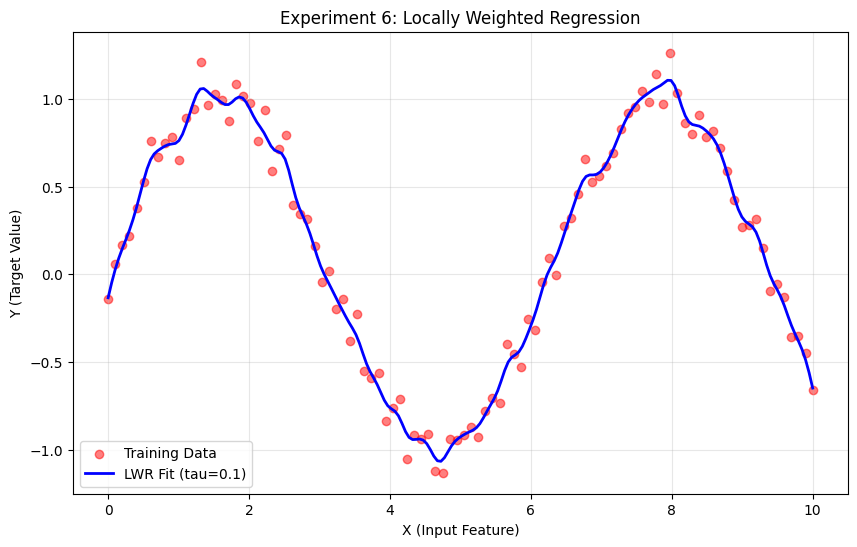

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Step 1: Define the Weighted Regression Logic ---
def gaussian_kernel(x, xi, tau):
    """Calculates weight: closer points get higher weight."""
    return np.exp(-np.sum((x - xi) ** 2) / (2 * tau ** 2))

def locally_weighted_regression(x, X, y, tau):
    """Predicts the value for a single point x using local weights."""
    m = X.shape[0]
    weights = np.array([gaussian_kernel(x, X[i], tau) for i in range(m)])
    W = np.diag(weights)
    
    # Normal Equation: theta = (X^T * W * X)^-1 * (X^T * W * y)
    X_transpose_W = X.T @ W
    try:
        theta = np.linalg.inv(X_transpose_W @ X) @ X_transpose_W @ y
        return x @ theta
    except np.linalg.LinAlgError:
        return None

# --- Step 2: Load your CSV Data ---
# Ensure lwr_dataset.csv is in the same folder!
df = pd.read_csv('lwr_dataset.csv')
X_data = df['X'].values
y_data = df['Y'].values

# Add a bias column (column of 1s) for the intercept
X_bias = np.c_[np.ones(X_data.shape), X_data]

# --- Step 3: Generate Predictions for a Smooth Curve ---
x_test = np.linspace(min(X_data), max(X_data), 200)
x_test_bias = np.c_[np.ones(x_test.shape), x_test]

# Change tau here to see the effect: 0.1 is smooth, 0.01 is wiggly
tau = 0.1 
y_pred = np.array([locally_weighted_regression(xi, X_bias, y_data, tau) for xi in x_test_bias])

# --- Step 4: Visualization ---
plt.figure(figsize=(10, 6))
plt.scatter(X_data, y_data, color='red', label='Training Data', alpha=0.5)
plt.plot(x_test, y_pred, color='blue', label=f'LWR Fit (tau={tau})', linewidth=2)

plt.xlabel('X (Input Feature)')
plt.ylabel('Y (Target Value)')
plt.title('Experiment 6: Locally Weighted Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

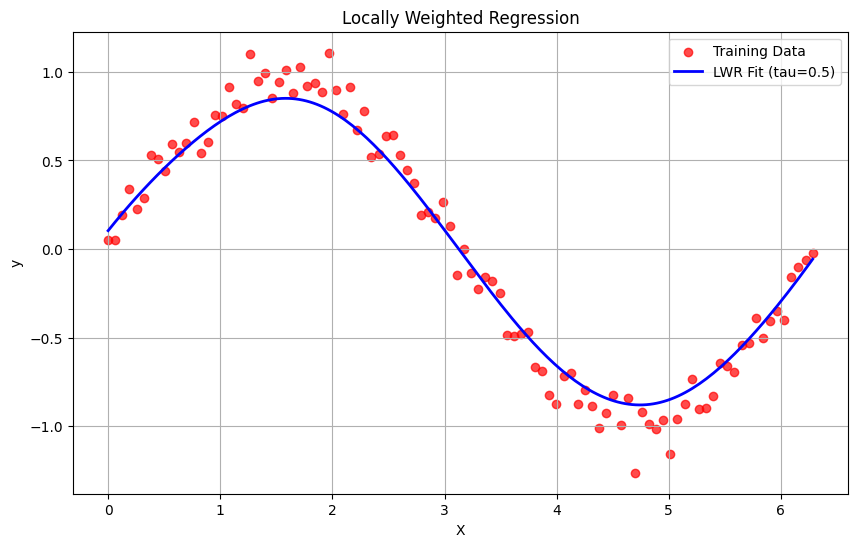

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Gaussian Kernel Function
def gaussian_kernel(x, xi, tau):
    return np.exp(-np.sum((x - xi) ** 2) / (2 * tau ** 2))

# Locally Weighted Regression Function
def locally_weighted_regression(x, X, y, tau):
    m = X.shape[0]
    
    # Compute weights
    weights = np.array([gaussian_kernel(x, X[i], tau) for i in range(m)])
    
    # Create diagonal weight matrix
    W = np.diag(weights)
    
    # Compute theta using weighted normal equation
    XTW = X.T @ W
    
    # Using pseudo-inverse for stability
    theta = np.linalg.pinv(XTW @ X) @ XTW @ y
    
    # Prediction
    return x @ theta

# Generate dataset
np.random.seed(42)
X = np.linspace(0, 2 * np.pi, 100)
y = np.sin(X) + 0.1 * np.random.randn(100)

# Add bias term
X_bias = np.c_[np.ones(X.shape), X]

# Test points
x_test = np.linspace(0, 2 * np.pi, 200)
x_test_bias = np.c_[np.ones(x_test.shape), x_test]

# Bandwidth parameter
tau = 0.5

# Predict values
y_pred = np.array([locally_weighted_regression(xi, X_bias, y, tau) 
                   for xi in x_test_bias])

# Plot results
plt.figure(figsize=(10, 6))

plt.scatter(X, y, color='red', label='Training Data', alpha=0.7)
plt.plot(x_test, y_pred, color='blue', label=f'LWR Fit (tau={tau})', linewidth=2)

plt.xlabel('X')
plt.ylabel('y')
plt.title('Locally Weighted Regression')
plt.legend()
plt.grid(True)

plt.show()